In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import os

np.random.seed(0)
torch.manual_seed(0)
os.environ["PYTHONHASHSEED"] = str(0)

# 1. Setup Data
device = "cuda" if torch.cuda.is_available() else "cpu"
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4), transforms.RandomHorizontalFlip(),
    transforms.ToTensor(), transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(), transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
train_loader = torch.utils.data.DataLoader(datasets.CIFAR10('./data', train=True, download=True, transform=transform_train), batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(datasets.CIFAR10('./data', train=False, download=True, transform=transform_test), batch_size=1000, shuffle=False)

# 2. Self-Organizing Model
class SelfOrganizingSchrodingerViT(nn.Module):
    def __init__(self, num_classes=10, patch_size=4, embed_dim=128, depth=6, num_heads=8):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (32 // patch_size) ** 2

        # ViT Backbone
        self.embed = nn.Linear(3 * patch_size**2, embed_dim)
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches + 1, embed_dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, batch_first=True, dim_feedforward=embed_dim*4, dropout=0.1),
            num_layers=depth
        )

        # HEADS
        self.head_V = nn.Linear(embed_dim, num_classes)
        self.head_M = nn.Linear(embed_dim, 1) # Variable Mass

        # --- LEARNABLE TOPOLOGY ---
        # Instead of a fixed matrix, we learn the weights between all classes.
        # We start with a random graph.
        # We use a parameter for the upper triangle to ensure symmetry.
        self.num_classes = num_classes
        # raw_weights: Learnable connectivity strength
        self.topology_weights = nn.Parameter(torch.randn(num_classes, num_classes) * 0.1)

    def get_kinetic_matrix(self):
        # 1. Enforce Symmetry: K must be symmetric for real eigenvalues
        W = 0.5 * (self.topology_weights + self.topology_weights.T)

        # 2. Enforce Positivity: Connection strengths must be non-negative
        W = F.softplus(W)

        # 3. Remove Self-Loops (Diagonal = 0)
        W = W * (1 - torch.eye(self.num_classes, device=W.device))

        # 4. Construct Laplacian: K = D - W
        # D is diagonal matrix of column sums
        D = torch.diag(torch.sum(W, dim=1))
        K = D - W

        # Scale K to keep physics in reasonable range
        return K

    def forward(self, x):
        B = x.shape[0]
        # Transformer Steps
        x = x.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size)
        x = x.contiguous().view(B, 3, self.num_patches, self.patch_size**2)
        x = x.permute(0, 2, 1, 3).contiguous().view(B, self.num_patches, -1)
        x = self.embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        x = x + self.pos_embed
        x = self.transformer(x)

        # Predict V and m
        V = self.head_V(x[:, 0])
        s = self.head_M(x[:, 0])
        m = 0.05 + 9.95 * torch.sigmoid(s)   # maps to [0.05,10]
        # m = F.softplus(self.head_M(x[:, 0])) + 0.1

        # Construct Dynamic Hamiltonian
        # Get the current learned topology
        K_learned = self.get_kinetic_matrix()
        K_learned = K_learned / (K_learned.abs().sum() + 1e-8) / K_learned.shape[0]  # Normalize to keep scale reasonable
        K_batch = K_learned.unsqueeze(0).expand(B, -1, -1)
        m_expanded = m.unsqueeze(-1)
        eps = 1e-3
        H = (1.0 / m_expanded) * (K_batch + eps * torch.eye(self.num_classes, device=K_batch.device).unsqueeze(0)) + torch.diag_embed(V)

        vals, vecs = torch.linalg.eigh(H)
        return vecs[:, :, 0], m, K_learned, V

100%|██████████| 170M/170M [00:03<00:00, 48.6MB/s]


In [5]:
# 4. Training Loop
model = SelfOrganizingSchrodingerViT().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
criterion = nn.NLLLoss()

print("Starting Self-Organizing Physics Training...")
print("-" * 75)

num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    total_nll = 0
    total_mass_loss = 0
    correct = 0
    total = 0
    avg_mass_stat = 0

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()

        # 1. Get Physics States
        # We explicitly capture m and K now
        psi, m, K_learned, _ = model(imgs)

        # 2. Primary Loss: Classification (Ground State)
        probs = psi.abs() ** 2
        probs = probs / (probs.sum(dim=-1, keepdim=True) + 1e-8)
        nll_loss = criterion(torch.log(probs + 1e-9), lbls)

        # 3. QUANTUM REGULARIZATION
        mass_penalty = 0.1 * m.mean()

        # Force Topology to be sparse (don't connect everything)
        # Only strong semantic connections should exist.
        topology_penalty = 0.001 * K_learned.abs().sum()

        # Total Loss
        loss = nll_loss + mass_penalty + topology_penalty

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        # Stats
        total_nll += nll_loss.item()
        total_mass_loss += mass_penalty.item()
        avg_mass_stat += m.mean().item()

        pred = probs.argmax(dim=-1)
        correct += (pred == lbls).sum().item()
        total += lbls.size(0)

    # Validation
    model.eval()
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            psi, _, _, _ = model(imgs)
            probs = psi.abs() ** 2
            test_correct += (probs.argmax(dim=-1) == lbls).sum().item()
            test_total += lbls.size(0)

    # Reporting
    print(f"Epoch: {epoch+1:<6}, NLL: {total_nll/len(train_loader):.4f}, Mass Loss: {total_mass_loss/len(train_loader):.4f}, Train Acc.: {correct/total:.4f}, Test Acc.: {test_correct/test_total:.4f}, Avg. Mass: {avg_mass_stat/len(train_loader):.4f}")


Starting Self-Organizing Physics Training...
---------------------------------------------------------------------------
Epoch: 1     , NLL: 3.3850, Mass Loss: 0.0077, Train Acc.: 0.1693, Test Acc.: 0.2340, Avg. Mass: 0.0765
Epoch: 2     , NLL: 2.0146, Mass Loss: 0.0051, Train Acc.: 0.3034, Test Acc.: 0.4231, Avg. Mass: 0.0512
Epoch: 3     , NLL: 1.7373, Mass Loss: 0.0051, Train Acc.: 0.3859, Test Acc.: 0.4427, Avg. Mass: 0.0508
Epoch: 4     , NLL: 1.5963, Mass Loss: 0.0051, Train Acc.: 0.4351, Test Acc.: 0.5109, Avg. Mass: 0.0506
Epoch: 5     , NLL: 1.4948, Mass Loss: 0.0050, Train Acc.: 0.4677, Test Acc.: 0.4977, Avg. Mass: 0.0505
Epoch: 6     , NLL: 1.4365, Mass Loss: 0.0050, Train Acc.: 0.4889, Test Acc.: 0.5167, Avg. Mass: 0.0504
Epoch: 7     , NLL: 1.3814, Mass Loss: 0.0050, Train Acc.: 0.5063, Test Acc.: 0.5374, Avg. Mass: 0.0504
Epoch: 8     , NLL: 1.3316, Mass Loss: 0.0050, Train Acc.: 0.5255, Test Acc.: 0.5568, Avg. Mass: 0.0504
Epoch: 9     , NLL: 1.2915, Mass Loss: 0.0050, 

In [6]:
# Visualization of the Learned "Phase Map"
def visualize_learned_topology(model):
    print("\nVisualizing the Self-Organized Semantic Topology...")
    classes = ['Plane', 'Car', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

    # Extract the learned Kinetic Matrix
    K = model.get_kinetic_matrix().detach().cpu().numpy()

    # Reconstruct Adjacency: The off-diagonals of K are -weights.
    # W_ij = -K_ij for i != j
    W = -K
    np.fill_diagonal(W, 0)

    # Build Graph
    G = nx.Graph()
    for i in range(10):
        G.add_node(classes[i])

    # Add edges for strong connections
    # We define "Strong" as top 30% of weights to avoid clutter
    threshold = np.percentile(W, 80)

    for i in range(10):
        for j in range(i+1, 10):
            weight = W[i, j]
            if weight > threshold:
                G.add_edge(classes[i], classes[j], weight=weight)

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, k=2.0, seed=42) # Spring layout effectively mimics the "Phase Circle"

    # Draw
    nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightblue')
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

    weights = [G[u][v]['weight'] * 2 for u,v in G.edges()]
    nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', alpha=0.6)

    plt.title("The Self-Organized Quantum Universe\n(Classes closer together allow easy tunneling)")
    plt.axis('off')
    plt.show()



Visualizing the Self-Organized Semantic Topology...


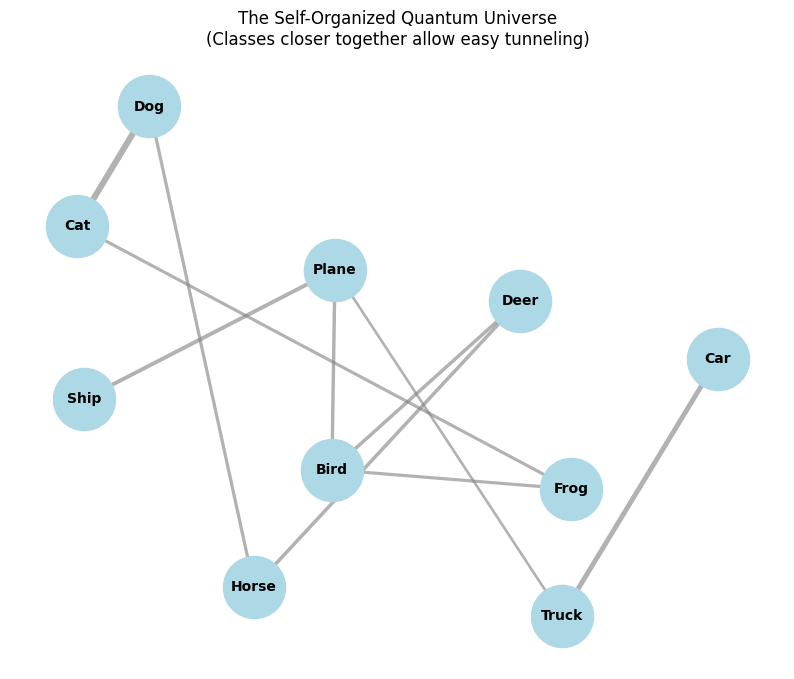

In [7]:
# Visualize the topology
visualize_learned_topology(model)

In [8]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def apply_anchored_surgical_tunnel(model, imgs, rule_from=3, rule_to=1):
    model.eval()
    with torch.no_grad():
        psi_orig, m, K_learned, V_orig = model(imgs)
        B = V_orig.shape[0]

        # 1. Calculate the 'Gating' logic so we only touches correct class
        initial_probs = psi_orig.abs()**2
        cat_prob = initial_probs[:, rule_from]
        gate = torch.sigmoid(20 * (cat_prob - 0.35))

        m_stable = torch.clamp(m, min=1e-3)
        m_inv = (1.0 / m_stable).view(B, 1, 1)
        H_base = m_inv * K_learned.unsqueeze(0) + torch.diag_embed(V_orig)

        # 2. THE ANCHOR: Deepen all other wells slightly to resist the tunnel
        # This acts like "frictional resistance" for non-target classes.
        anchor_strength = 2.0

        for b in range(B):
            strength = gate[b].item()

            # THE RULE (Push + Path)
            H_base[b, rule_from, rule_from] += strength * 30.0
            tc = strength * 5.0 * m_inv[b].item()
            H_base[b, rule_from, rule_to] -= tc
            H_base[b, rule_to, rule_from] -= tc

            # THE ANCHOR (Resistance)
            # We slightly lower the energy of all nodes EXCEPT the rule_to node
            # for images that should NOT be rule-following.
            if strength < 0.1:
                # This image is a "Stable" class. Make its current home even deeper.
                current_winner = initial_probs[b].argmax()
                H_base[b, current_winner, current_winner] -= anchor_strength

        vals, vecs = torch.linalg.eigh(H_base)
        return vecs[:, :, 0].abs()**2

In [10]:
#Rule Injection at Test Time:
def evaluate_rule_accuracy(model, test_loader, rule_from=3, rule_to=1):
    model.eval()

    compliance_count = 0
    total_from = 0

    stability_count = 0
    total_others = 0

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            # Apply the surgical tunnel rule
            probs_new = apply_anchored_surgical_tunnel(model, imgs, rule_from, rule_to)
            preds_new = probs_new.argmax(dim=-1)

            # 1. Check Targeted Compliance (The Rule)
            from_mask = (labels == rule_from)
            if from_mask.any():
                compliance_count += (preds_new[from_mask] == rule_to).sum().item()
                total_from += from_mask.sum().item()

            # 2. Check Global Integrity (Everything else)
            other_mask = ~from_mask
            if other_mask.any():
                stability_count += (preds_new[other_mask] == labels[other_mask]).sum().item()
                total_others += other_mask.sum().item()

    compliance_rate = (compliance_count / total_from) * 100 if total_from > 0 else 0
    stability_rate = (stability_count / total_others) * 100 if total_others > 0 else 0

    # print(f"\n--- RULE EVALUATION REPORT ---")
    print(f"Rule Compliance: {compliance_rate:.2f}%")
    print(f"Global Stability (Others):    {stability_rate:.2f}%")
    print(f"-------------------------------")
    return compliance_rate, stability_rate

In [11]:

classes = ['Plane', 'Car', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']
for i in range(10):
    for j in range(10):
        if i!=j:
            print(f"Applying new rule that route {classes[i]} to {classes[j]}")
            evaluate_rule_accuracy(model, test_loader, i, j)


Applying new rule that route Plane to Car
Rule Compliance: 90.90%
Global Stability (Others):    73.57%
-------------------------------
Applying new rule that route Plane to Bird
Rule Compliance: 89.50%
Global Stability (Others):    74.37%
-------------------------------
Applying new rule that route Plane to Cat
Rule Compliance: 89.50%
Global Stability (Others):    73.49%
-------------------------------
Applying new rule that route Plane to Deer
Rule Compliance: 89.00%
Global Stability (Others):    73.52%
-------------------------------
Applying new rule that route Plane to Dog


KeyboardInterrupt: 